#Voice

In [ ]:
!sudo apt-get update && sudo apt-get install ffmpeg -y
!pip install git+https://github.com/openai/whisper.git

In [ ]:
import whisper
model = whisper.load_model("medium")
rezultat_text = model.transcribe("/content/A1-0002_Audio1_00086952.wav")

print("\n Text: ")
print(rezultat_text["text"])

100%|█████████████████████████████████████| 1.42G/1.42G [00:30<00:00, 50.2MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



 Text: 
 La marginea împărăției lui mai trăia un alt împărat care, cât fusese tânăr, nu se lăsase doborât în luptă. Când cădea câte un pârloj asupra țării sale, el se făcea luntre și punte și-și scăpa țara.


In [ ]:
!pip install evaluate jiwer

import evaluate

# Încărcăm metrica Word Error Rate
wer_metric = evaluate.load("wer")

# Exemplu de evaluare:
text_real = ["salut mă bucur să te cunosc"]
text_generat_de_whisper = ["salut mă bucur să te recunosc"]

# Calculăm scorul (Înmulțim cu 100 ca să îl vedem în procente)
scor_wer = wer_metric.compute(predictions=text_generat_de_whisper, references=text_real) * 100

print(f"Scorul WER este: {scor_wer:.2f}% (Cât mai mic = Cât mai bine)")

In [ ]:
import re

def curata_text_whisper(text):
    if not text or not isinstance(text, str):
        return ""

    # 1. Eliminăm tag-urile de acțiuni/zgomote generate de Whisper
    # Ex: [Muzică], (tușește), *râde*
    text = re.sub(r'\[.*?\]|\(.*?\)|\*.*?\*', '', text)

    # 2. Eliminăm ezitările și cuvintele de umplutură (adaptat RO/EN)
    # Acoperă variații de: ăă, ăăă, îî, uh, um, hm
    fillers = r'\b(ăă+|îî+|uhm+|uh+|um+|hm+)\b'
    text = re.sub(fillers, '', text, flags=re.IGNORECASE)

    # 3. Corectăm spațiile dinaintea semnelor de punctuație
    # Ex: "salut , ce faci ?" -> "salut, ce faci?"
    text = re.sub(r'\s+([.,?!:;])', r'\1', text)

    # 4. Eliminăm repetițiile consecutive de cuvinte (halucinații scurte Whisper)
    # Ex: "Eu am am mers acolo" -> "Eu am mers acolo"
    text = re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', text, flags=re.IGNORECASE)

    # 5. Reducem spațiile multiple la un singur spațiu și curățăm capetele
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. (Opțional) Capitalizăm prima literă dacă s-a pierdut din cauza curățării
    if text:
        text = text[0].upper() + text[1:]

    return text

In [ ]:
text_curatat = curata_text_whisper(rezultat_text)
text_real = ["Aici se pune textul original!"]

# Calculare si printare scor wer.
scor_wer = wer_metric.compute(predictions=text_curatat, references=text_real) * 100

print(f"Scorul WER este: {scor_wer:.2f}% (Cât mai mic = Cât mai bine)")

#Text summary

In [ ]:
!pip install -U transformers accelerate peft bitsandbytes trl datasets

# Login

In [ ]:
from huggingface_hub import notebook_login

# Această funcție va deschide o căsuță interactivă
notebook_login()

# Dataset

In [ ]:
from datasets import load_dataset

# 1. Îi spunem exact care e fișierul de antrenament și care e cel de test
fisiere_date = {
    "train": "train_data.json",       # Pune numele corect al fișierului tău
    "validation": "test_data.json"    # Pune numele corect al fișierului tău
}

dataset = load_dataset("json", data_files=fisiere_date)

# 2. Funcția de șablon
def formateaza_prompt(exemple):
    texte_formatate = []
    for text_complicat, text_simplu in zip(exemple["text_complicat"], exemple["text_simplu"]):
        prompt = f"### Instrucțiune:\nScrie un rezumat concis și clar în limba română pentru următorul text.\n\n### Text:\n{text_complicat}\n\n### Rezumat:\n{text_simplu}"
        texte_formatate.append(prompt)
    return {"text": texte_formatate}

print("Se unesc textele și rezumatele...")
# Folosind .map(), va aplica formatarea automat pe AMBELE fișiere (train și validation)
dataset_formatat = dataset.map(formateaza_prompt, batched=True)

print(f"Pregătit: {len(dataset_formatat['train'])} texte de antrenament și {len(dataset_formatat['validation'])} texte de validare!")

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Se unesc textele și rezumatele...


Map:   0%|          | 0/327 [00:00<?, ? examples/s]

Map:   0%|          | 0/43 [00:00<?, ? examples/s]

Pregătit: 327 texte de antrenament și 43 texte de validare!


# Model Install


In [ ]:
import torch

torch.set_default_dtype(torch.float16)

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

nume_model = "meta-llama/Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Descărcăm LLaMA 3.2 8B (forțat pe Float16)...")
model = AutoModelForCausalLM.from_pretrained(
    nume_model,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16  # <--- SECRETUL ESTE AICI! Îl obligăm să renunțe la BFloat16
)
model.config.use_cache = False
# Falsificăm "certificatul de naștere" ca să nu mai creeze LoRA în BFloat16
model.config.torch_dtype = torch.float16

tokenizer = AutoTokenizer.from_pretrained(nume_model)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

Descărcăm LLaMA 3.2 8B (forțat pe Float16)...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

# Training

In [ ]:
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

# 1. Pregătim modelul pentru QLoRA
model = prepare_model_for_kbit_training(model)

# 2. Configurația LoRA
config_lora = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 3. Parametrii de antrenament MODERNIZAȚI
argumente_antrenament = SFTConfig(
    output_dir="./rezultate_llama_8b",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    optim="paged_adamw_8bit",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=5,
    learning_rate=2e-4,

    # SOLUȚIA AICI: Oprim ambele sisteme de mixed precision
    # din Trainer pentru a dezactiva GradScaler-ul!
    fp16=False,
    bf16=False,

    max_grad_norm=0.3,
    num_train_epochs=10,
    warmup_steps=20,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    dataset_text_field="text",
    max_length=1024,
)

# 4. Asamblăm SFTTrainer-ul
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset_formatat["train"],
    eval_dataset=dataset_formatat["validation"],
    peft_config=config_lora,
    processing_class=tokenizer,         # <--- Am schimbat "tokenizer" în "processing_class"
    args=argumente_antrenament,
)

print("Suntem gata! Start antrenament...")
trainer.train()

Adding EOS to train dataset:   0%|          | 0/327 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/327 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/43 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/43 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Suntem gata! Start antrenament...


Epoch,Training Loss,Validation Loss
1,1.721875,1.435656
2,1.626562,1.406971
3,1.495313,1.417451
4,1.323438,1.464921
5,1.217969,1.515675
6,1.057031,1.570526
7,0.929688,1.664452
8,0.846094,1.737817


KeyboardInterrupt: 

# Model upload

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# 1. Căile către modele
nume_model_baza = "meta-llama/Llama-3.1-8B-Instruct"
cale_adaptor_lora = "/content/rezultate_llama_8b/checkpoint-82" # <-- Verifică să fie calea corectă către folderul tău!

# 2. Încărcăm modelul de bază tot pe 4-bit ca să încapă în memorie
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("1. Se încarcă modelul de bază LLaMA...")
model_baza = AutoModelForCausalLM.from_pretrained(
    nume_model_baza,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(nume_model_baza)
tokenizer.pad_token = tokenizer.eos_token

print("2. Se atașează adaptorul tău (noul creier antrenat)...")
# Magia se întâmplă aici: combinăm LLaMA cu ce a învățat de la tine
model_rezumator = PeftModel.from_pretrained(model_baza, cale_adaptor_lora)
print("Model pregătit! Gata de generat.\n" + "="*40)

# 3. Funcția care face efectiv rezumatul
def genereaza_rezumat(text_lung):
    # TREBUIE să folosim EXACT același șablon (prompt) ca la antrenament!
    # Lăsăm secțiunea "### Rezumat:\n" goală, ca să o completeze el.
    prompt = f"### Instrucțiune:\nScrie un rezumat concis și clar în limba română pentru următorul text.\n\n### Text:\n{text_lung}\n\n### Rezumat:\n"

    # Transformăm textul în numere pentru model
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Generăm textul
    output_tokens = model_rezumator.generate(
        **inputs,
        max_new_tokens=300,  # Lungimea maximă a rezumatului generat
        temperature=0.3,     # Cât de "creativ" să fie. 0.3 este bine pentru rezumate stricte.
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decodificăm rezultatul din numere înapoi în litere
    rezultat_complet = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

    # Textul generat conține și prompt-ul nostru. Extragem doar ce a scris el la final!
    rezumat_final = rezultat_complet.split("### Rezumat:\n")[-1].strip()

    return rezumat_final

# ==========================================
# 🧪 TESTEAZĂ-ȚI MODELUL AICI!
# ==========================================

text_de_test = """
Inteligența artificială (IA) a devenit un subiect central în discuțiile globale,
datorită avansurilor rapide din ultimii ani. Companiile investesc miliarde de dolari
pentru a dezvolta sisteme capabile să automatizeze sarcini complexe, de la diagnosticarea
medicală până la conducerea autonomă a vehiculelor. Cu toate acestea, experții avertizează
că o reglementare strictă este necesară pentru a preveni utilizările abuzive, cum ar fi
generarea de știri false sau încălcarea intimității utilizatorilor. Uniunea Europeană a
adoptat recent primul set de legi dedicate exclusiv reglementării IA, încercând să găsească
un echilibru între inovație și siguranța publică.
"""

rezumat = genereaza_rezumat(text_de_test)

print("\nTEXT ORIGINAL:")
print(text_de_test)
print("\nREZUMAT GENERAT DE MODELUL TĂU:")
print(rezumat)

KeyboardInterrupt: 

# Results

In [ ]:
!pip install evaluate
!pip install sacrebleu
!pip install rouge_score

In [ ]:
import matplotlib.pyplot as plt

def plot_ter_score(ter_dict):
    # 1. Extragem datele
    ter_score = round(ter_dict['score'] * 100, 2)
    edits = ter_dict['num_edits']
    ref_len = ter_dict['ref_length']

    # 2. Setăm dimensiunea (îl facem un pic mai îngust pentru că avem doar o bară)
    fig, ax = plt.subplots(figsize=(6, 5))

    # 3. Creăm bara (Culoare de "Atenție" pentru că vrem scor mic)
    x_labels = ['TER\n(Rata de Eroare)']
    bars = ax.bar(x_labels, [ter_score], color=['#E6550D'], width=0.4)

    # 4. Adăugăm procentul deasupra
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (ter_score * 0.05), f'{yval}%',
                ha='center', va='bottom', fontweight='bold')

    # 5. Formatăm aspectul
    # Axa Y este dinamică, în caz că TER-ul depășește 100%
    ax.set_ylim(0, max(100, ter_score + 20))
    ax.set_ylabel('Eroare (%) - Cât mai MIC e mai bine', fontsize=12)
    ax.set_title('Analiza TER (Translation Edit Rate)', fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 6. Caseta de detalii
    summary_text = (f"Scor TER: {ter_score}%\n"
                    f"Modificări necesare: {edits}\n"
                    f"Lungime referință: {ref_len} cuv.\n"
                    f"(Ținta ideală = 0%)")

    props = dict(boxstyle='round', facecolor='#f4f4f4', alpha=0.9, edgecolor='gray')
    ax.text(0.95, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_bleu_score(sacrebleu_dict):
    bleu_score = round(sacrebleu_dict['score'], 2)
    precisions = [round(p, 2) for p in sacrebleu_dict['precisions']]
    bp = round(sacrebleu_dict['bp'], 3)
    sys_len = sacrebleu_dict['sys_len']
    ref_len = sacrebleu_dict['ref_len']

    fig, ax = plt.subplots(figsize=(8, 5))

    x_labels = ['1-gram\n(Cuvinte)', '2-gram\n(Bigrame)', '3-gram\n(Trigrame)', '4-gram\n(Tetragrame)']
    culori = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    bars = ax.bar(x_labels, precisions, color=culori)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval}%',
                ha='center', va='bottom', fontweight='bold')

    ax.set_ylim(0, 115) # Ajustat pentru vizibilitate
    ax.set_ylabel('Precizie (%)', fontsize=12)
    ax.set_title('Analiza Preciziilor N-grame (sacreBLEU)', fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    summary_text = (f"Scor BLEU Final: {bleu_score}\n"
                    f"Penalizare Brevitate (BP): {bp}\n"
                    f"Cuvinte generate: {sys_len}\n"
                    f"Cuvinte referință: {ref_len}")

    props = dict(boxstyle='round', facecolor='#f4f4f4', alpha=0.9, edgecolor='gray')
    ax.text(0.95, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_rouge_score(rouge_dict):
    # 1. Extragem datele și le transformăm în procente
    r1 = round(rouge_dict['rouge1'] * 100, 2)
    r2 = round(rouge_dict['rouge2'] * 100, 2)
    rl = round(rouge_dict['rougeL'] * 100, 2)
    rlsum = round(rouge_dict['rougeLsum'] * 100, 2)

    scoruri = [r1, r2, rl, rlsum]

    # 2. Setăm dimensiunea graficului
    fig, ax = plt.subplots(figsize=(8, 5))

    # 3. Creăm barele pentru metricele ROUGE
    x_labels = ['ROUGE-1\n(Cuvinte)', 'ROUGE-2\n(Bigrame)', 'ROUGE-L\n(Cea mai lungă\nsecvență)', 'ROUGE-Lsum']
    culori = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    bars = ax.bar(x_labels, scoruri, color=culori)

    # 4. Adăugăm procentele deasupra fiecărei bare
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval}%',
                ha='center', va='bottom', fontweight='bold')

    # 5. Formatăm aspectul (axe, titlu, grid)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Scor (%)', fontsize=12)
    ax.set_title('Analiza Scorurilor ROUGE', fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 6. Adăugăm o casetă cu un mini-rezumat / legendă
    summary_text = (f"Ghid de interpretare:\n"
                    f"ROUGE-1: Vocabular / Idei cheie\n"
                    f"ROUGE-2: Gramatică / Fluență\n"
                    f"ROUGE-L: Structura propoziției")

    props = dict(boxstyle='round', facecolor='#f4f4f4', alpha=0.9, edgecolor='gray')
    ax.text(0.95, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    # 7. Afișăm graficul
    plt.tight_layout()
    plt.show()

# Apelarea corectă folosind variabila ta anterioară:
# plot_rouge_score(rezultate)

In [ ]:
import evaluate

print("Se descarcă și se încarcă judecătorii (metricile)...")
metrica_bleu = evaluate.load("sacrebleu")
metrica_rouge = evaluate.load("rouge")
metrica_ter = evaluate.load("ter")
print("Metrici încărcate cu succes! Acum poți rula funcția de testare.")

Se descarcă și se încarcă judecătorii (metricile)...


Metrici încărcate cu succes! Acum poți rula funcția de testare.


🤖 Modelul LLaMA generează rezumatul. Te rog așteaptă...

📝 REZUMATUL TĂU DE REFERINȚĂ:
Deși nu s-a demonstrat clar dacă Nicolae Ceaușescu a ordonat deschiderea focului împotriva manifestanților, vărsarea de sânge i-a pecetluit soarta. Indiferent dacă violențele de la Timișoara și București au fost provocate de el sau de serviciile secrete străine, scopul și rezultatul final au fost aceleași: transformarea sa definitivă într-un criminal în fața opiniei publice.
--------------------------------------------------
✨ REZUMATUL GENERAT DE AI:
Deși nu se știe cu certitudine dacă a dat ordinul de a împușca, moartea a fost un eveniment strategic perfect pentru a-l face să pară un criminal. Acest lucru a fost planificat în secret de agenți străini, care au dorit să-l facă să semene cu un dictator dintr-un film de groază.

📊 PLOTARE REZULTATE:


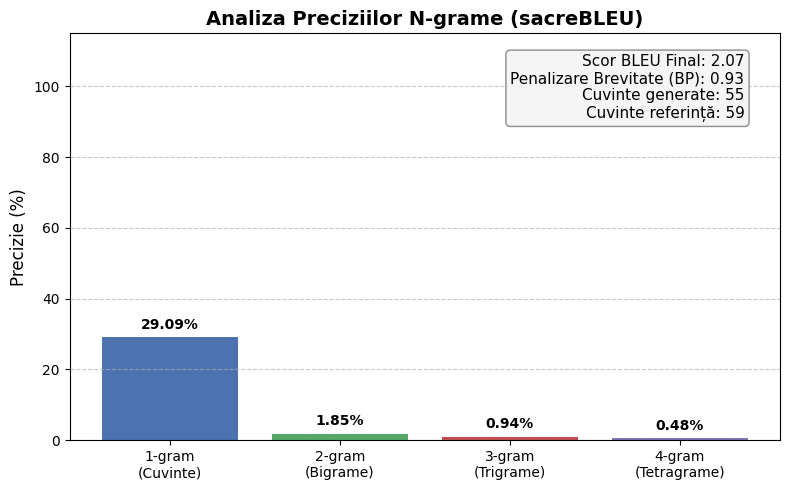

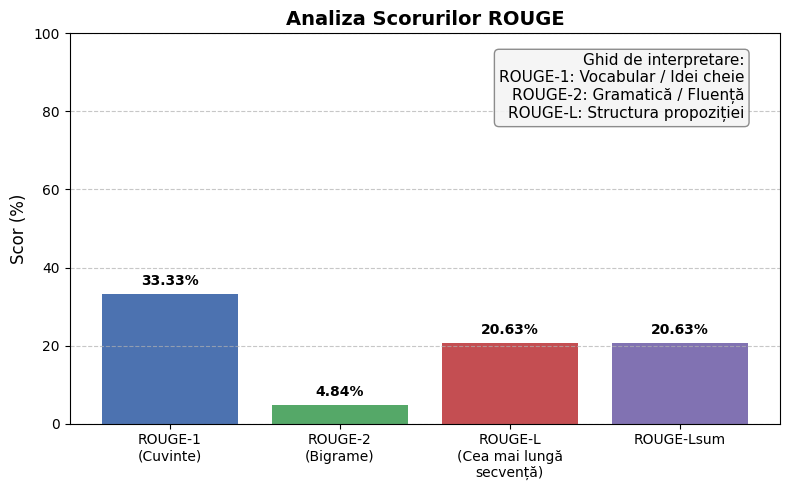

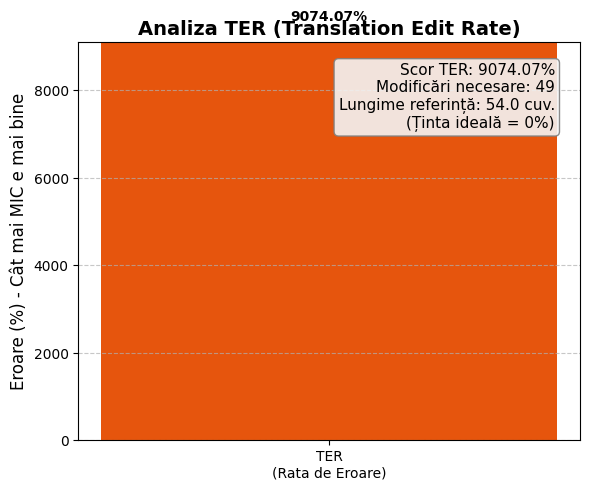

In [ ]:
def TesteazaSiPloteazaMaster(text_sursa, rezumat_referinta_uman):
    print("🤖 Modelul LLaMA generează rezumatul. Te rog așteaptă...")

    # 1. Generarea
    rezumat_ai = genereaza_rezumat(text_sursa)

    print("\n" + "="*50)
    print("📝 REZUMATUL TĂU DE REFERINȚĂ:")
    print(rezumat_referinta_uman)
    print("-" * 50)
    print("✨ REZUMATUL GENERAT DE AI:")
    print(rezumat_ai)
    print("="*50)

    # 2. Calculul TOATUROR metricilor
    # Trecem predictiile și referințele în formatul cerut de HuggingFace (liste)
    rezultat_bleu = metrica_bleu.compute(predictions=[rezumat_ai], references=[[rezumat_referinta_uman]])
    rezultat_rouge = metrica_rouge.compute(predictions=[rezumat_ai], references=[rezumat_referinta_uman])
    rezultat_ter = metrica_ter.compute(predictions=[rezumat_ai], references=[[rezumat_referinta_uman]])

    # 3. Desenăm cele 3 grafice pe rând
    print("\n📊 PLOTARE REZULTATE:")
    plot_bleu_score(rezultat_bleu)
    plot_rouge_score(rezultat_rouge)
    plot_ter_score(rezultat_ter)


# ==========================================
# 🧪 TESTEAZĂ TOTUL AICI
# ==========================================

text_test = """
Soarta lui Ceaușescu era în acel moment pecetluită. A dat sau nu ordin să se tragă fostul dictator? Toate investigațiile ulterioare n-au reușit să ofere un răspuns precis. Sigur e că vărsarea de sînge nevinovat n-a fost în interesul lui Ceaușescu. Fiecare mort în plus anunțat de posturile de radio occidentale, de zvoneri, sporeau cantitatea de sînge de pe mîinile lui Ceaușescu.
Operă a lui Ceaușescu sau operă a serviciilor secrete străine, sîngele vărsat la Timișoara sau București a avut menirea de a face din Ceaușescu un criminal.
"""

referinta = """Deși nu s-a demonstrat clar dacă Nicolae Ceaușescu a ordonat deschiderea focului împotriva manifestanților, vărsarea de sânge i-a pecetluit soarta. Indiferent dacă violențele de la Timișoara și București au fost provocate de el sau de serviciile secrete străine, scopul și rezultatul final au fost aceleași: transformarea sa definitivă într-un criminal în fața opiniei publice."""

# Lăsăm magia să se întâmple
TesteazaSiPloteazaMaster(text_test, referinta)

🤖 Modelul LLaMA generează rezumatul. Te rog așteaptă...

📝 REZUMATUL TĂU DE REFERINȚĂ:
"Cetatea Țărănească din Saschiz, un monument istoric din secolul 
al XIV-lea recent restaurat, a fost redeschisă publicului în weekenduri, urmând 
să aibă un program zilnic pe durata sezonului cald. Construită inițial de 
comunitatea săsească pentru apărare și păstrarea proviziilor, fortificația 
reprezintă astăzi un simbol important al istoriei și ingineriei medievale din 
Transilvania.

--------------------------------------------------
✨ REZUMATUL GENERAT DE AI:
Cetatea Țărănească din Saschiz a fost redeschisă vizitatorilor, fiind accesibilă în fiecare weekend. În sezonul cald, obiectivul va putea fi vizitat în fiecare zi, iar programul de vizitare va fi anunțat în următoarele zile.

📊 PLOTARE REZULTATE:


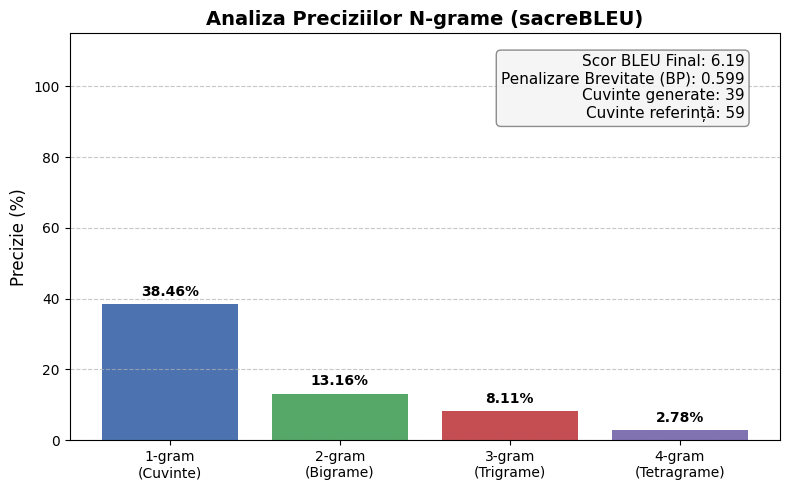

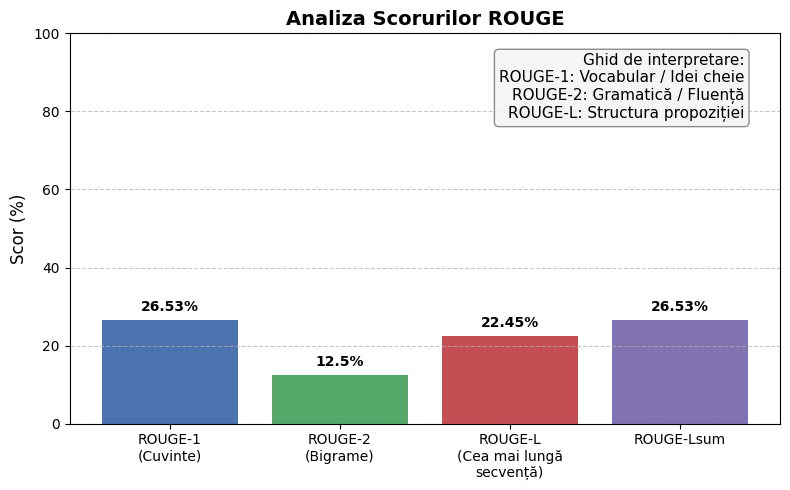

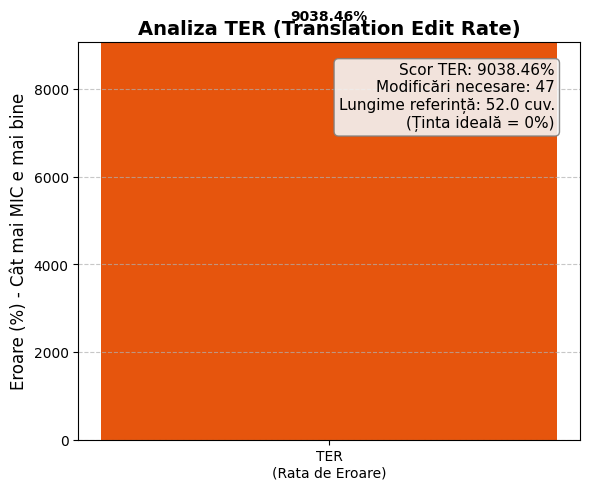

In [ ]:
text2 = """
Asociația Visit Mureș a anunțat că Cetatea Țărănească din Saschiz, construită
în secolul al XIV-lea, va fi redeschisă pentru vizitatori în fiecare sfârșit de săptămână.
„Cetatea Țărănească din Saschiz este din nou deschisă vizitatorilor și îi
așteaptă în prezent pe turiști în fiecare weekend, de vineri până duminică.
Accesul se face pietonal, fie pe traseul din centrul satului (aproximativ 2 kilometri),
fie pe varianta mai scurtă, de la barieră (aproximativ 700 de metri). Programul pentru
sezonul cald va fi anunțat în curând, așa că merită să urmăriți pagina de Facebook a
cetății pentru mai multe informații”, a anunțat Visit Mureș pe Facebook.
Pe pagina de Facebook Cetatea de Refugiu Saschiz se precizează că în sezonul
cald obiectivul va putea fi vizitat în fiecare zi, iar programul de vizitare
urmează să fie anunțat în următoarele zile. Cetatea țărănească din Saschiz a fost
ridicată în 1347 pe un deal din apropierea localității. Construită de localnici,
după marea invazie mongolă din 1241, cetatea a servit pentru apărare și ca spațiu de
depozitare a alimentelor, menținând o temperatură constantă, care prevenea alterarea
proviziilor.Ajunsă în ruină după Al Doilea Război Mondial, când sașii transilvăneni
au fost persecutați de autoritățile bolșevice ruse și apoi de cele comuniste din România,
astăzi cetatea a fost restaurată, fiind o mărturie a ingineriei și a spiritului de
cooperare al comunității medievale săsești din Transilvania."""

rezumat2 =""""Cetatea Țărănească din Saschiz, un monument istoric din secolul
al XIV-lea recent restaurat, a fost redeschisă publicului în weekenduri, urmând
să aibă un program zilnic pe durata sezonului cald. Construită inițial de
comunitatea săsească pentru apărare și păstrarea proviziilor, fortificația
reprezintă astăzi un simbol important al istoriei și ingineriei medievale din
Transilvania.
"""
TesteazaSiPloteazaMaster(text_sursa=text2, rezumat_referinta_uman=rezumat2)